# <center> Предсказание рейтинга отелей

# Введение


**Какой кейс решаем?**\
Одна из проблем компании — это нечестные отели, которые накручивают себе рейтинг. Одним из способов обнаружения таких отелей является построение модели, которая предсказывает рейтинг отеля. Если предсказания модели сильно отличаются от фактического результата, то, возможно, отель ведёт себя нечестно, и его стоит проверить.

Первоначальная версия датасета содержит 17 полей со следующей информацией:

hotel_address — адрес отеля;  
review_date — дата, когда рецензент разместил соответствующий отзыв;  
average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;  
hotel_name — название отеля;  
reviewer_nationality — страна рецензента;  
negative_review — отрицательный отзыв, который рецензент дал отелю;  
review_total_negative_word_counts — общее количество слов в отрицательном отзыв;  
positive_review — положительный отзыв, который рецензент дал отелю;  
review_total_positive_word_counts — общее количество слов в положительном отзыве.  
reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;  
total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;  
total_number_of_reviews — общее количество действительных отзывов об отеле;    
tags — теги, которые рецензент дал отелю;  
days_since_review — количество дней между датой проверки и датой очистки;  
additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв.   Это число указывает, сколько там действительных оценок без проверки.  
lat — географическая широта отеля;  
lng — географическая долгота отеля.  

 [Ссылка на работу на Kaggle](https://www.kaggle.com/code/alexandrarkhireev33/baseline-v1/edit/run/273486791)

In [ ]:
import numpy as np # для вычислений
import pandas as pd # для работы с данными

# импортируем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# Загружаем специальный удобный инструмент для разделения датасета:
from sklearn.model_selection import train_test_split
# Импортируем необходимые библиотеки:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели
from typing import Counter

In [22]:
# фиксипуем сид 
RANDOM_SEED = 42

In [23]:
# зафиксируем версию пакетов, чтобы эксперименты были воспроизводимы:
!pip freeze > requirements.txt

In [24]:
df_train = pd.read_csv('D:/IDE/data/hotels_train.csv') # датасет для обучения
df_test = pd.read_csv('D:/IDE/data/hotels_test.csv') # датасет для предсказания
sample_submission = pd.read_csv('D:/IDE/data/submission.csv') # самбмишн

# Знакомство с данными

In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [26]:
df_train.head(5)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


In [27]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

In [28]:
df_test.head(5)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520
3,Piazza Della Repubblica 17 Central Station 201...,241,10/17/2015,9.1,Hotel Principe Di Savoia,United States of America,No Negative,0,1543,Everything including the nice upgrade The Hot...,27,9,"[' Leisure trip ', ' Couple ', ' Ambassador Ju...",656 day,45.479888,9.196298
4,Singel 303 309 Amsterdam City Center 1012 WJ A...,834,5/16/2016,9.1,Hotel Esther a,United Kingdom,No Negative,0,4687,Lovely hotel v welcoming staff,7,2,"[' Business trip ', ' Solo traveler ', ' Class...",444 day,52.370545,4.888644


In [29]:
sample_submission.head(2)

,reviewer_score,id
0,1,488440
1,10,274649


In [30]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   reviewer_score  128935 non-null  int64
 1   id              128935 non-null  int64
dtypes: int64(2)
memory usage: 2.0 MB


In [ ]:
# ВАЖНО! дря корректной обработки признаков объединяем трейн и тест в один датасет
df_train['sample'] = 1 # помечаем где у нас трейн
df_test['sample'] = 0 # помечаем где у нас тест
df_test['reviewer_score'] = 0 # в тесте у нас нет значения reviewer_score, мы его должны предсказать, по этому пока просто заполняем нулями
hotels = pd.concat([df_test, df_train], sort=False).reset_index(drop=True) # объединяем дата-сеты

In [32]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515738 non-null  object 
 1   additional_number_of_scoring                515738 non-null  int64  
 2   review_date                                 515738 non-null  object 
 3   average_score                               515738 non-null  float64
 4   hotel_name                                  515738 non-null  object 
 5   reviewer_nationality                        515738 non-null  object 
 6   negative_review                             515738 non-null  object 
 7   review_total_negative_word_counts           515738 non-null  int64  
 8   total_number_of_reviews                     515738 non-null  int64  
 9   positive_review                             515738 non-null  object 
 

In [33]:
print(f'Количество отелей {hotels["hotel_name"].nunique()}')
hotels['review_date'] = pd.to_datetime(hotels['review_date'])
print(f'Первый отзыв {hotels["review_date"].min()}')
print(f'Последний отзыв {hotels["review_date"].max()}')


Количество отелей 1492
Первый отзыв 2015-08-04 00:00:00
Последний отзыв 2017-08-03 00:00:00


In [34]:
top_hotels = hotels['hotel_name'].value_counts()[:10]
print(f'Топ-10 популярных отелей \n {top_hotels}')

Топ-10 популярных отелей 
 hotel_name
Britannia International Hotel Canary Wharf           4789
Strand Palace Hotel                                  4256
Park Plaza Westminster Bridge London                 4169
Copthorne Tara Hotel London Kensington               3578
DoubleTree by Hilton Hotel London Tower of London    3212
Grand Royale London Hyde Park                        2958
Holiday Inn London Kensington                        2768
Hilton London Metropole                              2628
Millennium Gloucester Hotel London                   2565
Intercontinental London The O2                       2551
Name: count, dtype: int64


# Работа с признакми

Сначала переделаем признак days_since_review — количество дней между датой проверки и датой очистки, в признак который будет показывать когда этот отзыв был оставлен.  
Для этого вычтем из даты последнего оставленного отзыва в датасете (которую будем считать датой наблюдений) даты каждого из отзывов

In [35]:
hotels['days_since_review'] = hotels["review_date"].max() - hotels['review_date']

Теперь закодируем в признак fresh_review информацию свежий ли это отзыв или старый (старше или новее 90 дней)

In [36]:
hotels['fresh_review'] = hotels['days_since_review'].apply(lambda x: 1 if x.days <= 90 else 0)
hotels['fresh_review'].value_counts()

fresh_review
0    446335
1     69403
Name: count, dtype: int64

Взглянем на признак Tags поближе может, найдется что-то важное

In [37]:
hotels['tags'] = hotels['tags'].apply(lambda x: x.replace('[','').replace(']','').replace("' ",'').replace(" '",'').split(','))

In [38]:
uniq_tag = []
for x,y in enumerate(hotels['tags']):
    for j in y:
            uniq_tag.append(j.strip().lower())

unique_tags = pd.DataFrame(Counter(uniq_tag).most_common())
unique_tags.columns = ['tag', 'count']


Выведем 20 самых популярных

In [39]:
unique_tags[:20]

,tag,count
0,leisure trip,417778
1,submitted from a mobile device,307640
2,couple,252294
3,stayed 1 night,193645
4,stayed 2 nights,133937
5,solo traveler,108545
6,stayed 3 nights,95821
7,business trip,82939
8,group,65392
9,family with young children,61015


Вряд ли какие либо из этих тегов могут влиять на рейтинг отелей, в них информация скорее о клиентах и их выборе, а не отеле

В признаках, которые показывают количество слов в негативных и положительных отзывах явно ошибки, завышающие число слов, испраим.

In [40]:
hotels['review_total_negative_word_counts'] = hotels['negative_review'].apply(lambda x: len(x.split()))
hotels['review_total_positive_word_counts'] = hotels['positive_review'].apply(lambda x: len(x.split()))

Проверяем наличие пропусков в признаках широты и долготы

In [41]:
display(hotels['lat'].isna().value_counts())
display(hotels['lng'].isna().value_counts())

lat
False    512470
True       3268
Name: count, dtype: int64

lng
False    512470
True       3268
Name: count, dtype: int64

Заполнить пропущеные значения координат, с той же точностью, что и у других обьектов можно только собрав данные из внешних источников или вручную.  


In [42]:
unknow_coordiantes = hotels[hotels['lat'].isna() == True]['hotel_address']
unknow_coordiantes.value_counts()

hotel_address
Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria    658
Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria            563
W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria       389
4 rue de la P pini re 8th arr 75008 Paris France               290
Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria         245
W hringer Stra e 12 09 Alsergrund 1090 Vienna Austria          223
Savoyenstra e 2 16 Ottakring 1160 Vienna Austria               194
Sieveringer Stra e 4 19 D bling 1190 Vienna Austria            147
Bail n 4 6 Eixample 08010 Barcelona Spain                      146
Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria             93
Hasenauerstra e 12 19 D bling 1190 Vienna Austria               61
Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria        57
23 Rue Damr mont 18th arr 75018 Paris France                    55
Paragonstra e 1 11 Simmering 1110 Vienna Austria                49
20 Rue De La Ga t 14th arr 75014 Paris France   

Для максимальной точности я выбрал способ собрать данные вручную

In [43]:
#собираем данные координат отелей и заносим в переменную
coor_to_fill = [('Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria', 48.211222, 16.346028),
                ('Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria', 48.216389, 16.382222),
                ('W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria',48.221667,16.358889),
                ('4 rue de la P pini re 8th arr 75008 Paris France', 48.874722, 2.316111),
                ('Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria', 48.1925, 16.391389),
                ('W hringer Stra e 12 09 Alsergrund 1090 Vienna Austria', 48.221111, 16.358611),
                ('Savoyenstra e 2 16 Ottakring 1160 Vienna Austria', 48.215833, 16.331389),
                ('Sieveringer Stra e 4 19 D bling 1190 Vienna Austria', 48.249444, 16.339722),
                ('Bail n 4 6 Eixample 08010 Barcelona Spain', 41.391389, 2.175833),
                ('Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria', 48.226389, 16.360556),
                ('Hasenauerstra e 12 19 D bling 1190 Vienna Austria', 48.230556, 16.343889),
                ('Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria', 48.210833, 16.3475),
                ('23 Rue Damr mont 18th arr 75018 Paris France', 48.891389, 2.339722),
                ('Paragonstra e 1 11 Simmering 1110 Vienna Austria', 48.170833, 16.421111),
                ('20 Rue De La Ga t 14th arr 75014 Paris France', 48.8325, 2.323333),
                ('Pau Clar s 122 Eixample 08009 Barcelona Spain', 41.395278, 2.168889),
                ('Sep lveda 180 Eixample 08011 Barcelona Spain', 41.385833, 2.156667)]

#заполняем пропущенные значения собранными данными из списка
for add, lat, lng in coor_to_fill:
    hotels.loc[hotels['hotel_address'] == add, 'lat'] = lat
    hotels.loc[hotels['hotel_address'] == add, 'lng'] = lng

Выделим страну отеля

In [44]:
hotels['country'] = hotels['hotel_address'].apply(lambda x: 'UK' if 'United Kingdom' in x else x.split()[-1])
hotels['country'].value_counts()

country
UK             262301
Spain           60149
France          59928
Netherlands     57214
Austria         38939
Italy           37207
Name: count, dtype: int64

Затем город

In [45]:
hotels['hotel_city'] = hotels['hotel_address'].apply(lambda x: x.split()[-5] if 'United Kingdom' in x else x.split()[-2])
hotels['hotel_city'].value_counts()

hotel_city
London       262301
Barcelona     60149
Paris         59928
Amsterdam     57214
Vienna        38939
Milan         37207
Name: count, dtype: int64

Можно предположить, что если отель находится в столице, то это будет положительно влиять на рейтинг


Как можно было увидеть ранее, в наших данных представлены только 6 европейсих стран. Поэтому лекго вручную создать список с городами-столицами этих стран

In [46]:
hotel_capitals = ['London', 'Madrid', 'Paris', 'Amsterdam', 'Vienna', 'Rome']

Далее закодируем признак capital, где 1 это показатель того, что город является столицей, 0 нет

In [47]:
hotels['capital'] = hotels['hotel_city'].apply(lambda x: 1 if x in hotel_capitals else 0)

# Корреляция признаков

<Axes: >

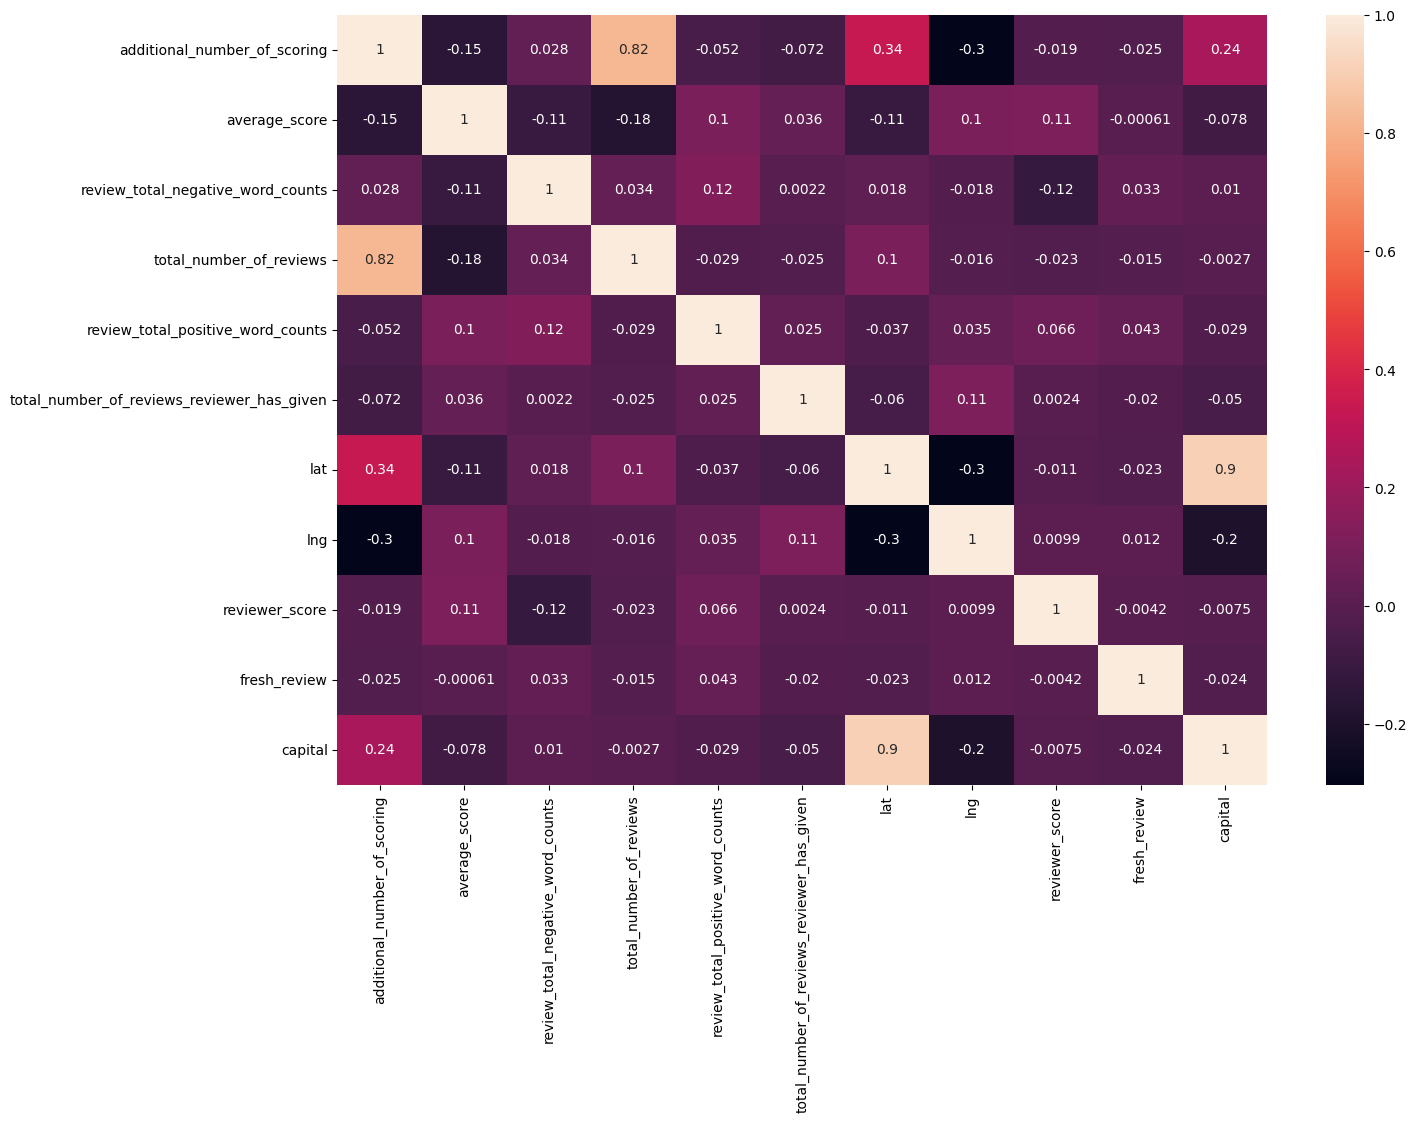

In [49]:
plt.rcParams['figure.figsize'] = (15,10)
sns.heatmap(hotels.drop(['sample'], axis=1).corr(numeric_only=True), annot=True)

# Обучение модели

In [50]:
# убираем признаки которые еще не успели обработать, 
# модель на признаках с dtypes "object" обучаться не будет, просто выберим их и удалим
object_columns = [s for s in hotels.columns if hotels[s].dtypes == 'object']
hotels.drop(object_columns, axis = 1, inplace=True)
hotels.drop(['review_date','days_since_review'], axis=1, inplace=True)

Удалим сильно скореллированные признаки

In [51]:
hotels.drop(['additional_number_of_scoring','lat', 'lng'], axis=1, inplace=True)

In [52]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 9 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   average_score                               515738 non-null  float64
 1   review_total_negative_word_counts           515738 non-null  int64  
 2   total_number_of_reviews                     515738 non-null  int64  
 3   review_total_positive_word_counts           515738 non-null  int64  
 4   total_number_of_reviews_reviewer_has_given  515738 non-null  int64  
 5   sample                                      515738 non-null  int64  
 6   reviewer_score                              515738 non-null  float64
 7   fresh_review                                515738 non-null  int64  
 8   capital                                     515738 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 35.4 MB


In [53]:
# Теперь выделим тестовую часть
train_data = hotels.query('sample == 1').drop(['sample'], axis=1)
test_data = hotels.query('sample == 0').drop(['sample'], axis=1)

y = train_data.reviewer_score.values            # наш таргет
X = train_data.drop(['reviewer_score'], axis=1)

In [54]:
# Воспользуемся специальной функцие train_test_split для разбивки тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [55]:
# проверяем
test_data.shape, train_data.shape, X.shape, X_train.shape, X_test.shape

((128935, 8), (386803, 8), (386803, 7), (309442, 7), (77361, 7))

In [57]:
# Создаём модель 
model = RandomForestRegressor(n_estimators=100, verbose=1, n_jobs=-1, random_state=RANDOM_SEED)

In [58]:
# Обучаем модель на тестовом наборе данных
model.fit(X_train, y_train)

# Используем обученную модель для предсказания рейтинга ресторанов в тестовой выборке.
# Предсказанные значения записываем в переменную y_pred
y_pred = model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   10.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.5s finished


In [62]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они в среднем отличаются
# Метрика называется Mean Absolute Error (MAE) и показывает среднее отклонение предсказанных значений от фактических.
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))

MAPE: 0.1423923207909506
MAE: 0.9888695812847981


<Axes: >

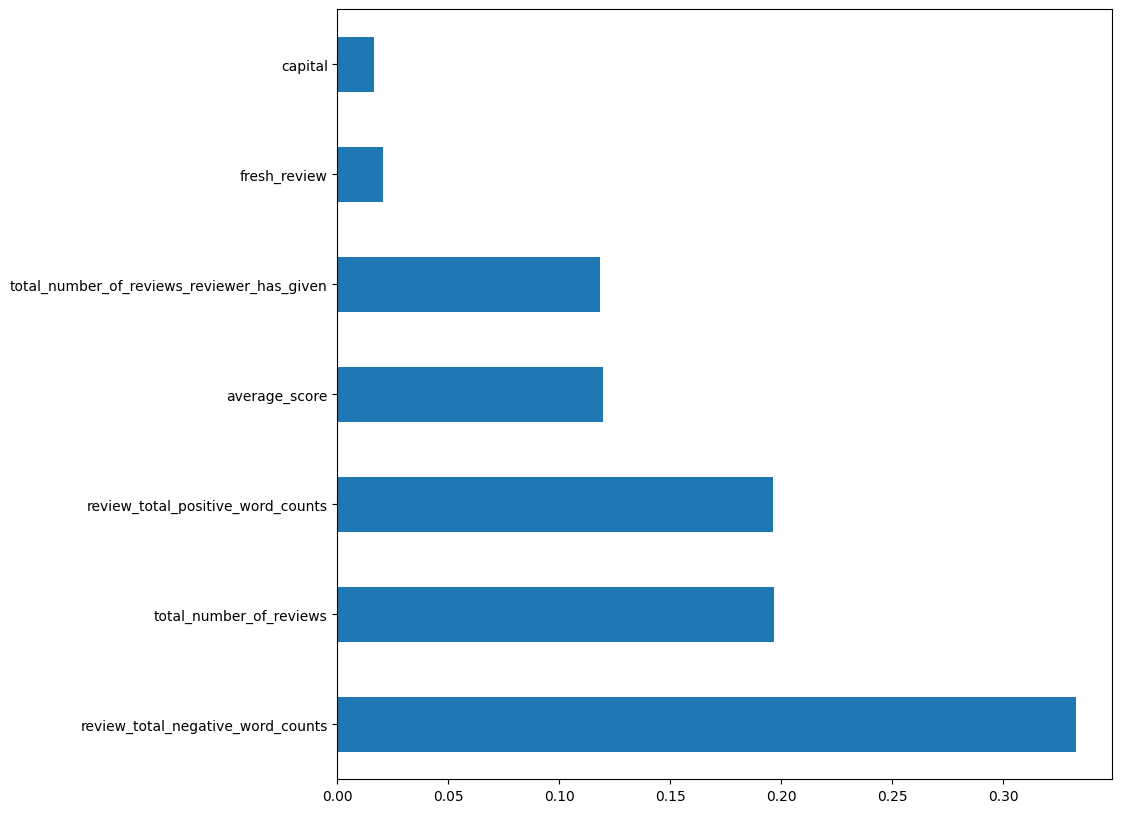

In [63]:
# в RandomForestRegressor есть возможность вывести самые важные признаки для модели
plt.rcParams['figure.figsize'] = (10,10)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')

In [64]:
test_data.sample(10)

,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,fresh_review,capital
8101,8.8,9,1324,2,1,0.0,0,1
37892,8.4,12,6117,39,23,0.0,0,1
107323,8.9,45,857,47,14,0.0,0,1
100902,8.4,32,4410,2,2,0.0,1,1
24205,8.4,11,1664,4,1,0.0,1,0
79927,8.1,19,1560,31,1,0.0,1,0
55341,8.1,7,7105,29,1,0.0,0,1
58946,8.8,34,4305,1,1,0.0,0,1
109273,8.9,15,2924,14,16,0.0,0,1
122300,8.4,4,6117,16,1,0.0,0,1


In [65]:
test_data = test_data.drop(['reviewer_score'], axis=1)

In [66]:
sample_submission

,reviewer_score,id
0,1,488440
1,10,274649
2,3,374688
3,10,404352
4,9,451596
...,...,...
128930,7,495812
128931,1,315577
128932,3,511968
128933,6,303386


In [67]:
predict_submission = model.predict(test_data)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.7s finished


In [68]:
predict_submission

array([8.674     , 7.327     , 8.786     , ..., 8.322     , 9.401     ,
       6.68726667])

In [69]:
list(sample_submission)

['reviewer_score', 'id']

In [70]:
sample_submission['reviewer_score'] = predict_submission
sample_submission.to_csv('submission.csv', index=False)
sample_submission.head(10)

,reviewer_score,id
0,8.674000,488440
1,7.327000,274649
2,8.786000,374688
3,9.478000,404352
4,8.996569,451596
5,8.997000,302161
6,7.195333,317079
7,8.373000,13963
8,9.119133,159785
9,8.454000,195089
